In [1]:

# --- Import Required Libraries ---

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [2]:

# --- Load and Explore the Dataset ---

# The dataset includes delivery attributes like distance, traffic, weight, and time taken
df = pd.read_csv("https://raw.githubusercontent.com/saikisri97/Optimisation/master/For_AI_Lecture/data/simulated_delivery_data.csv")

# Select relevant input features and target variable
features = ['Distance_km', 'Traffic_Level', 'Package_Weight']
target = 'Time_taken_min'

X = df[features]
y = df[target]


In [3]:

# --- Feature Scaling ---

# Normalize input features using StandardScaler for better neural network performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [4]:

# --- Train-Test Split ---

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [5]:

# --- Build the Neural Network Model ---

# Create a simple feedforward neural network (fully connected)
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # First hidden layer
    Dense(32, activation='relu'),                                   # Second hidden layer
    Dense(1)                                                        # Output layer for regression
])

# Compile the model with Mean Squared Error loss and Adam optimizer
model.compile(optimizer='adam', loss='mse')

# Train the model over 50 epochs
history = model.fit(X_train, y_train, epochs=50, verbose=0)


/opt/miniconda3/envs/argos_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:

# --- Evaluate Predictions ---

# Predict delivery time for the test set
y_pred = model.predict(X_test).flatten()
y_true = y_test.values


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


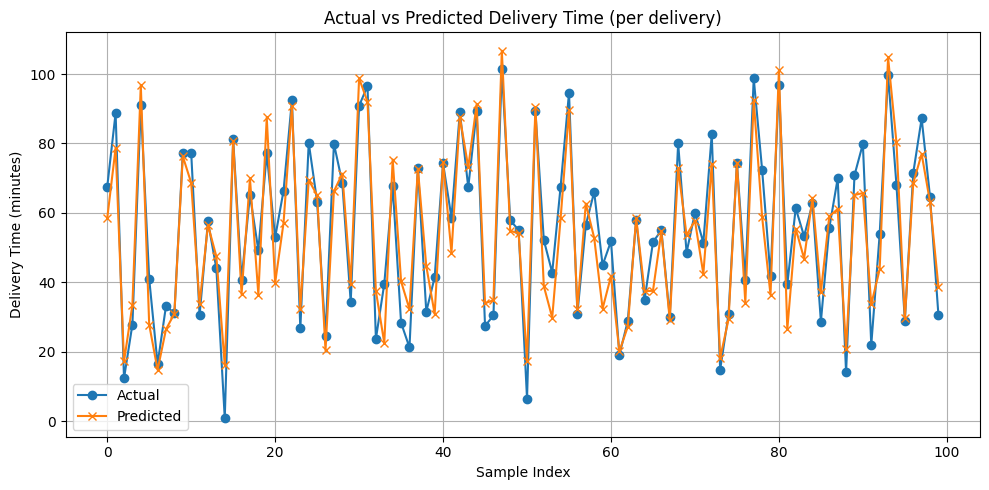

In [7]:

# --- Visualization 1: Line Plot by Index ---

plt.figure(figsize=(10, 5))
plt.plot(y_true, label="Actual", marker='o')
plt.plot(y_pred, label="Predicted", marker='x')
plt.xlabel("Sample Index")
plt.ylabel("Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time (per delivery)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


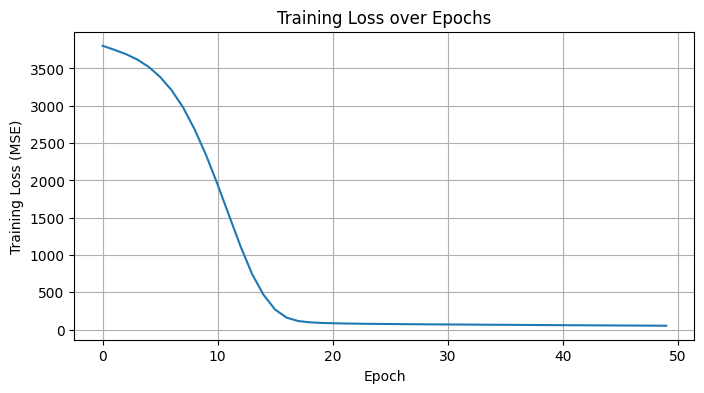

In [9]:

# --- Optional: Plot Training Loss Curve ---

# This helps to visualize how the model's error reduced over time
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()
